In [26]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as plt
import seaborn as sns
import fiona
from shapely import Point

# Loading the Data

In [2]:
#Create the data frames for the data from each police force
herts_raw = pd.DataFrame(columns=['Crime ID','Month','Reported by','Falls within','Longitude','Latitude','Location','LSOA code','LSOA name','Crime type','Last outcome category','Context'])
kent_raw = pd.DataFrame(columns=['Crime ID','Month','Reported by','Falls within','Longitude','Latitude','Location','LSOA code','LSOA name','Crime type','Last outcome category','Context'])
surrey_raw = pd.DataFrame(columns=['Crime ID','Month','Reported by','Falls within','Longitude','Latitude','Location','LSOA code','LSOA name','Crime type','Last outcome category','Context'])
essex_raw = pd.DataFrame(columns=['Crime ID','Month','Reported by','Falls within','Longitude','Latitude','Location','LSOA code','LSOA name','Crime type','Last outcome category','Context'])

data = ('Data')
cd = os.path.abspath('')
cwd = os.path.abspath(os.path.join(cd,data))

In [3]:
#Make a list of all files in current working directory
list(os.listdir(cwd))
x=0
#Make a list for each police force
herts_list = []
kent_list = []
surrey_list = []
essex_list = []

#Populate lists with the files for each police force
for i in os.listdir(cwd):
    if 'hertfordshire' in os.listdir(cwd)[x]:
        herts_list.append(os.listdir(cwd)[x])
    if 'kent' in os.listdir(cwd)[x]:
        kent_list.append(os.listdir(cwd)[x])
    if 'surrey' in os.listdir(cwd)[x]:
        surrey_list.append(os.listdir(cwd)[x])
    if 'essex' in os.listdir(cwd)[x]:
        essex_list.append(os.listdir(cwd)[x])
    x = x + 1

In [4]:
#Combine each .csv into a single dataframe
x=0
for i in herts_list:
    herts_load = pd.read_csv(cwd+'\\'+herts_list[x])
    herts_raw = pd.concat([herts_raw,herts_load])
    x=x+1
x=0
for i in kent_list:
    kent_load = pd.read_csv(cwd+'\\'+kent_list[x])
    kent_raw = pd.concat([kent_raw,kent_load])
    x=x+1
x=0
for i in surrey_list:
    surrey_load = pd.read_csv(cwd+'\\'+surrey_list[x])
    surrey_raw = pd.concat([surrey_raw,surrey_load])
    x=x+1
x=0
for i in essex_list:
    essex_load = pd.read_csv(cwd+'\\'+essex_list[x])
    essex_raw = pd.concat([essex_raw,essex_load])
    x=x+1

C:\Users\andre\AppData\Local\Temp\ipykernel_12220\3682900485.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  herts_raw = pd.concat([herts_raw,herts_load])
C:\Users\andre\AppData\Local\Temp\ipykernel_12220\3682900485.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  kent_raw = pd.concat([kent_raw,kent_load])
C:\Users\andre\AppData\Local\Temp\ipykernel_12220\3682900485.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future versi

In [5]:
essex_data = essex_raw
herts_data = herts_raw
kent_data = kent_raw
surrey_data = surrey_raw

In [6]:
#Load the population data for the LSOAs
lsoa_pop22 = pd.read_excel(cwd+'\\'+'sapelsoabroadage20222024.xlsx','Mid-2022 LSOA 2021',skiprows=3)

lsoa_pop23 = pd.read_excel(cwd+'\\'+'sapelsoabroadage20222024.xlsx','Mid-2023 LSOA 2021',skiprows=3)

lsoa_pop24 = pd.read_excel(cwd+'\\'+'sapelsoabroadage20222024.xlsx','Mid-2024 LSOA 2021',skiprows=3)

lsoa_pop_median = pd.read_excel(cwd+'\\'+'sapelsoabroadage20222024.xlsx','Median age LSOA 2011-2024',skiprows=3)

In [8]:
#Load the population data for the PFAs
pfa_pop = pd.read_excel(cwd+'\\'+'policeforceareas1991to2024.xlsx','Mid-2021 to Mid-2024',skiprows=3)

In [9]:
#Location data for the PFAs
fiona.drvsupport.supported_drivers['libkml'] = 'rw' 
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'

essex_boundary = gpd.read_file(cwd+'\\'+'esse.kml',driver='libkml')
herts_boundary = gpd.read_file(cwd+'\\'+'herts.kml',driver='libkml')
kent_boundary = gpd.read_file(cwd+'\\'+'ken.kml',driver='libkml')
surrey_boundary = gpd.read_file(cwd+'\\'+'surre.kml',driver='libkml')

# Audit the Data

## Police forces:

In [10]:
#Using .shape to show number of rows and columns in each dataset
print('Essex:',essex_data.shape)
print('Herts:',herts_data.shape)
print('Kent:',kent_data.shape)
print('Surrey:',surrey_data.shape)
#Largest datasets are Essex (1032129 rows) and Kent (1158777 rows) while smallest are Herts (616545 rows) and Surrey (527730 rows). 
#They each have 12 columns

#Using .info() to show count of non-nulls and data type for each column
essex_data.info()
herts_data.info()
kent_data.info()
surrey_data.info()
#Context column in each has no non-null values, can safely be dropped
#Some rows have no crimeID, last outcome category, longitude, latitude or LSOA data

Essex: (344043, 12)
Herts: (205515, 12)
Kent: (386259, 12)
Surrey: (175910, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 344043 entries, 0 to 13019
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               310316 non-null  object 
 1   Month                  344043 non-null  object 
 2   Reported by            344043 non-null  object 
 3   Falls within           344043 non-null  object 
 4   Longitude              339484 non-null  float64
 5   Latitude               339484 non-null  float64
 6   Location               344043 non-null  object 
 7   LSOA code              339484 non-null  object 
 8   LSOA name              339484 non-null  object 
 9   Crime type             344043 non-null  object 
 10  Last outcome category  310316 non-null  object 
 11  Context                0 non-null       object 
dtypes: float64(2), object(10)
memory usage: 34.1+ MB
<class 'pandas.core

In [11]:
#Visual audit of the data

#essex_data.head(10)
#herts_data.head(10)
#kent_data.head(10)
surrey_data.head(10)

#The month column holds data for both year and month
#In the location column some non-null values do not hold a location, just 'On or near'

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,ea70d2edb3f0e5be2e90e6a2b66c1b50b04b0380c5e418...,2022-07,Surrey Police,Surrey Police,0.145491,51.549552,On or near Osborne Square,E01000017,Barking and Dagenham 009C,Vehicle crime,Status update unavailable,NaN
1,44928179d944db9af2956bd19370f9ed02fa79e0107d46...,2022-07,Surrey Police,Surrey Police,0.165560,51.545110,On or near,E01000036,Barking and Dagenham 010B,Violence and sexual offences,Status update unavailable,NaN
2,e69642066d666002331271b3d8d5e47191e640be2e745b...,2022-07,Surrey Police,Surrey Police,-1.137273,51.226355,On or near Bronze Close,E01032849,Basingstoke and Deane 021F,Violence and sexual offences,Status update unavailable,NaN
3,ce86fea17253af2219ac105b4413d807b3d40065e8fac3...,2022-07,Surrey Police,Surrey Police,-1.737938,53.815496,On or near Grovelands,E01010598,Bradford 028B,Violence and sexual offences,Status update unavailable,NaN
4,8a31fb43f5277b9842291b6204e4fdfcce4518b2071ef2...,2022-07,Surrey Police,Surrey Police,-0.128234,50.818614,On or near Charlotte Street,E01016944,Brighton and Hove 031E,Violence and sexual offences,Status update unavailable,NaN
5,05da8639a84ae5af9ac41c913d040dd7ddead4660f7148...,2022-07,Surrey Police,Surrey Police,-1.198600,51.950011,On or near,E01028477,Cherwell 011B,Violence and sexual offences,Status update unavailable,NaN
6,5f2d2a4e4aa8dcf3c2c804bbe6e33980f773c2be242b11...,2022-07,Surrey Police,Surrey Police,-2.900109,53.279177,On or near York Road,E01018520,Cheshire West and Chester 007B,Other crime,Status update unavailable,NaN
7,7f2a29d1c81acf74661edfd64a37d2c1b724a7a755a1aa...,2022-07,Surrey Police,Surrey Police,-0.101292,51.514770,On or near Amen Court,E01032739,City of London 001F,Violence and sexual offences,Unable to prosecute suspect,NaN
8,e31bca13f13bf825a405d0f3f6debc7442bdbfe4fe3bde...,2022-07,Surrey Police,Surrey Police,-0.101292,51.514770,On or near Amen Court,E01032739,City of London 001F,Violence and sexual offences,Unable to prosecute suspect,NaN
9,8cb3923d15a1b75c39d98117c33f82c9ba53d16010cda1...,2022-07,Surrey Police,Surrey Police,-0.101292,51.514770,On or near Amen Court,E01032739,City of London 001F,Violence and sexual offences,Investigation complete; no suspect identified,NaN


In [301]:
#Investigating why some CrimeID values are null

#essex_nullID = essex_data[essex_data['Crime ID'].isnull()==True]
#essex_nullID['Crime type'].unique()
#herts_nullID = herts_data[herts_data['Crime ID'].isnull()==True]
#herts_nullID['Crime type'].unique()
#kent_nullID = kent_data[kent_data['Crime ID'].isnull()==True]
#kent_nullID['Crime type'].unique()
#surrey_nullID = surrey_data[surrey_data['Crime ID'].isnull()==True]
#surrey_nullID['Crime type'].unique()

#Only antisocial behaviour offences are shown
#After some research, the reason for this may be that Anti-social behaviour doesn't count as a crime. 
#As a result, the null values in CrimeID should not be removed, but reflect this fact.

In [302]:
#Investigating missing location data

#essex_nullID = essex_data[essex_data['Latitude'].isnull()==True]
#essex_nullID
#herts_nullID = herts_data[herts_data['Latitude'].isnull()==True]
#herts_nullID
#kent_nullID = kent_data[kent_data['Latitude'].isnull()==True]
#kent_nullID
#surrey_nullID = surrey_data[surrey_data['Latitude'].isnull()==True]
#surrey_nullID

#For each of these rows, location is not null but has the value 'No Location'
#There seems to be no common theme for each of these rows
#essex_nullID.shape[0]/essex_data.shape[0]*100 #1.33% of the data
#herts_nullID.shape[0]/herts_data.shape[0]*100 #1.61% of the data
#kent_nullID.shape[0]/kent_data.shape[0]*100 #0.99% of the data
#surrey_nullID.shape[0]/surrey_data.shape[0]*100 #2.08% of the data

#Since location data is important, and makes up a very small proportion of the data, each of these rows should be removed

## LSOA population:

In [303]:
#Using .shape to show number of rows and columns in each dataset
print('2022:',lsoa_pop22.shape)
print('2023:',lsoa_pop23.shape)
print('2024:',lsoa_pop24.shape)
print('Median:',lsoa_pop_median.shape)

#Using .info() to show count of non-nulls and data type for each column
lsoa_pop22.info()
lsoa_pop23.info()
lsoa_pop24.info()
lsoa_pop_median.info()

2022: (35672, 15)
2023: (35672, 15)
2024: (35672, 15)
Median: (35672, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35672 entries, 0 to 35671
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   LAD 2023 Code   35672 non-null  object
 1   LAD 2023 Name   35672 non-null  object
 2   LSOA 2021 Code  35672 non-null  object
 3   LSOA 2021 Name  35672 non-null  object
 4   Total           35672 non-null  int64 
 5   F0 to 15        35672 non-null  int64 
 6   F16 to 29       35672 non-null  int64 
 7   F30 to 44       35672 non-null  int64 
 8   F45 to 64       35672 non-null  int64 
 9   F65 and over    35672 non-null  int64 
 10  M0 to 15        35672 non-null  int64 
 11  M16 to 29       35672 non-null  int64 
 12  M30 to 44       35672 non-null  int64 
 13  M45 to 64       35672 non-null  int64 
 14  M65 and over    35672 non-null  int64 
dtypes: int64(11), object(4)
memory usage: 4.1+ MB
<class 'pandas.cor

In [21]:
#Visual audit of the data
#lsoa_pop22
#lsoa_pop23
#lsoa_pop24
#lsoa_pop_median

#Data seems clean but contains alot of irrelevant data from LSOAs that are not under the jurisdiction of the four chosen forces
#lsoa_pop22, lsoa_pop23, and lsoa_pop24 should be merged together, however, each needs a year column first to differentiate the data

## PFA population:

In [305]:
#Using .shape to show number of rows and columns in each dataset
print('PFA pop:',pfa_pop.shape)
#The dataset has 172 rows and 178 columns

#Using .info() to show count of non-nulls and data type for each column
pfa_pop.info()
#Since there are so many columns, all entries cannot be shown

PFA pop: (172, 178)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Columns: 178 entries, PFA 2023 Code to TOTAL
dtypes: float64(1), int64(175), object(2)
memory usage: 239.3+ KB


In [306]:
#Visual audit of the data
pfa_pop

#Total column is full of nulls

,PFA 2023 Code,PFA 2023 Name,Year,F0,F1,F2,F3,F4,F5,F6,...,M79,M80,M81,M82,M83,M84,M85,FTOTAL,MTOTAL,TOTAL
0,E23000001,Metropolitan Police,2021,51645,52111,51165,51033,51843,52101,51137,...,14156,12511,13118,12214,11284,10136,51460,4532174,4263906,NaN
1,E23000001,Metropolitan Police,2022,53387,51282,51393,50706,50616,51641,52319,...,15113,13373,11745,12245,11321,10450,52766,4572840,4286913,NaN
2,E23000001,Metropolitan Police,2023,51047,53405,51051,51359,50792,50682,52018,...,15945,14302,12562,10881,11329,10369,53824,4634699,4351400,NaN
3,E23000001,Metropolitan Police,2024,51526,51041,52918,50777,51276,50664,50846,...,15658,15144,13481,11793,10164,10433,55460,4673259,4401366,NaN
4,E23000002,Cumbria,2021,2069,2089,2198,2182,2384,2432,2374,...,1913,1733,1660,1509,1392,1257,5864,254206,246523,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,W15000003,South Wales,2024,5834,6011,6383,6338,6919,7015,7244,...,4402,4109,3501,3143,2706,2512,12387,694528,669033,NaN
168,W15000004,Dyfed-Powys,2021,1972,2176,2205,2340,2377,2554,2535,...,2187,1873,1814,1638,1467,1352,6458,263587,252415,NaN
169,W15000004,Dyfed-Powys,2022,2039,2027,2265,2282,2397,2434,2607,...,2362,2080,1777,1704,1498,1350,6587,265343,254221,NaN
170,W15000004,Dyfed-Powys,2023,1902,2098,2096,2295,2332,2472,2481,...,2525,2204,1956,1649,1576,1374,6738,267042,255515,NaN


## PFA Boundary:

In [18]:
#Using .shape to show number of rows and columns in each dataset
print('Essex:',essex_boundary.shape)
print('Herts',herts_boundary.shape)
print('Kent',kent_boundary.shape)
print('Surrey',surrey_boundary.shape)
#Each boundary dataframe has 1 row and 13 columns

#Using .info() to show count of non-nulls and data type for each column
essex_boundary.info()
herts_boundary.info()
kent_boundary.info()
surrey_boundary.info()
#Most columns apart from the 'Name' and 'geometry' columns are metadata carried over from the .kml format and can be dropped
#Most columns are null, the 'Name' column will need to be filled in with the name of the boundary

Essex: (1, 13)
Herts (1, 13)
Kent (1, 13)
Surrey (1, 13)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            0 non-null      object        
 1   Name          0 non-null      object        
 2   description   0 non-null      object        
 3   timestamp     0 non-null      datetime64[ms]
 4   begin         0 non-null      datetime64[ms]
 5   end           0 non-null      datetime64[ms]
 6   altitudeMode  0 non-null      object        
 7   tessellate    1 non-null      int32         
 8   extrude       1 non-null      int32         
 9   visibility    1 non-null      int32         
 10  drawOrder     0 non-null      float64       
 11  icon          0 non-null      object        
 12  geometry      1 non-null      geometry      
dtypes: datetime64[ms](3), float64(1), geometry(1), int32(3), object(5)
memory usage

In [20]:
#Geometry is a multipolygon z
#essex_boundary
#herts_boundary
#kent_boundary
#surrey_boundary

# Data Cleaning

## Police Forces:

In [308]:
#Remove the empty 'Context' column from each dataset
essex_data.drop('Context',axis=1,inplace=True)
herts_data.drop('Context',axis=1,inplace=True)
kent_data.drop('Context',axis=1,inplace=True)
surrey_data.drop('Context',axis=1,inplace=True)

In [309]:
#Fill null values in the 'Crime ID' column
essex_data.fillna({'Crime ID':'Not Crime'},inplace=True)
herts_data.fillna({'Crime ID':'Not Crime'},inplace=True)
kent_data.fillna({'Crime ID':'Not Crime'},inplace=True)
surrey_data.fillna({'Crime ID':'Not Crime'},inplace=True)

In [310]:
#Fill 'Last Outcome Category' with no data, for ASBs
essex_data.fillna({'Last outcome category':'No data'},inplace=True)
herts_data.fillna({'Last outcome category':'No data'},inplace=True)
kent_data.fillna({'Last outcome category':'No data'},inplace=True)
surrey_data.fillna({'Last outcome category':'No data'},inplace=True)

In [311]:
#Remove rows with null location data
essex_data.dropna(how='any',axis=0,inplace=True)
herts_data.dropna(how='any',axis=0,inplace=True)
kent_data.dropna(how='any',axis=0,inplace=True)
surrey_data.dropna(how='any',axis=0,inplace=True)

In [312]:
#Split years and months into two columns
#essex
essex_split = essex_data['Month'].str.split('-',expand=True)
essex_split.columns = ['Year','Month']

essex_data = essex_data.drop('Month',axis=1)
essex_data.insert(1,'Month',essex_split['Month'])
essex_data.insert(1,'Year',essex_split['Year'])

#hertfordshire
herts_split = herts_data['Month'].str.split('-',expand=True)
herts_split.columns = ['Year','Month']

herts_data = herts_data.drop('Month',axis=1)
herts_data.insert(1,'Month',herts_split['Month'])
herts_data.insert(1,'Year',herts_split['Year'])

#kent
kent_split = kent_data['Month'].str.split('-',expand=True)
kent_split.columns = ['Year','Month']

kent_data = kent_data.drop('Month',axis=1)
kent_data.insert(1,'Month',kent_split['Month'])
kent_data.insert(1,'Year',kent_split['Year'])

#surrey
surrey_split = surrey_data['Month'].str.split('-',expand=True)
surrey_split.columns = ['Year','Month']

surrey_data = surrey_data.drop('Month',axis=1)
surrey_data.insert(1,'Month',surrey_split['Month'])
surrey_data.insert(1,'Year',surrey_split['Year'])

In [314]:
essex_data.info()
herts_data.info()
kent_data.info()
surrey_data.info()
#All nulls in the data have been either filled or dropped
#As a result, data should be fully cleaned and should be ready for Analysis

<class 'pandas.core.frame.DataFrame'>
Index: 339484 entries, 0 to 12642
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               339484 non-null  object 
 1   Year                   339484 non-null  object 
 2   Month                  339484 non-null  object 
 3   Reported by            339484 non-null  object 
 4   Falls within           339484 non-null  object 
 5   Longitude              339484 non-null  float64
 6   Latitude               339484 non-null  float64
 7   Location               339484 non-null  object 
 8   LSOA code              339484 non-null  object 
 9   LSOA name              339484 non-null  object 
 10  Crime type             339484 non-null  object 
 11  Last outcome category  339484 non-null  object 
dtypes: float64(2), object(10)
memory usage: 33.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 202213 entries, 0 to 9197
Data columns (total 12 colum

## LSOA Population:

In [22]:
#To make the dataset more lightweight, population data that doesn't relate to an LSOA in one of the datasets should not be kept 
lsoa_pop22[lsoa_pop22['LSOA 2021 Code'].isin(essex_data['LSOA code'].unique())==True]
lsoa_pop22[lsoa_pop22['LSOA 2021 Code'].isin(herts_data['LSOA code'].unique())==True]
lsoa_pop22[lsoa_pop22['LSOA 2021 Code'].isin(kent_data['LSOA code'].unique())==True]
lsoa_pop22[lsoa_pop22['LSOA 2021 Code'].isin(surrey_data['LSOA code'].unique())==True]
#There seems to be data in locations, such as Cardiff and Middlesbrough in the Herts data, that are outside of the PFA of that data's police force

,LAD 2023 Code,LAD 2023 Name,LSOA 2021 Code,LSOA 2021 Name,Total,F0 to 15,F16 to 29,F30 to 44,F45 to 64,F65 and over,M0 to 15,M16 to 29,M30 to 44,M45 to 64,M65 and over
614,E06000007,Warrington,E01012558,Warrington 023D,1687,131,120,153,299,152,141,119,145,282,145
1918,E06000018,Nottingham,E01013816,Nottingham 022D,4544,77,2093,130,104,52,85,1700,141,115,47
2592,E06000022,Bath and North East Somerset,E01014482,Bath and North East Somerset 012D,1336,133,94,97,215,147,145,103,70,201,131
3866,E06000033,Southend-on-Sea,E01015854,Southend-on-Sea 015D,2166,195,386,228,203,84,202,296,266,233,73
4027,E06000034,Thurrock,E01033612,Thurrock 020D,1565,186,107,212,208,45,207,128,199,223,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33708,E09000033,Westminster,E01004733,Westminster 020C,2181,83,419,226,237,141,153,365,217,198,142
33709,E09000033,Westminster,E01004734,Westminster 018A,1796,32,275,189,185,119,46,268,308,235,139
34402,W06000011,Swansea,W01000739,Swansea 014B,2310,197,275,292,237,140,206,234,348,252,129
35062,W06000016,Rhondda Cynon Taf,W01001171,Rhondda Cynon Taf 017A,1284,101,94,127,173,152,126,82,139,161,129


Essex loading...
Essex loaded
Hertfordshire loading...
Hertfordshire loaded
Kent loading...
Kent loaded
Surrey loading...
Surrey loaded


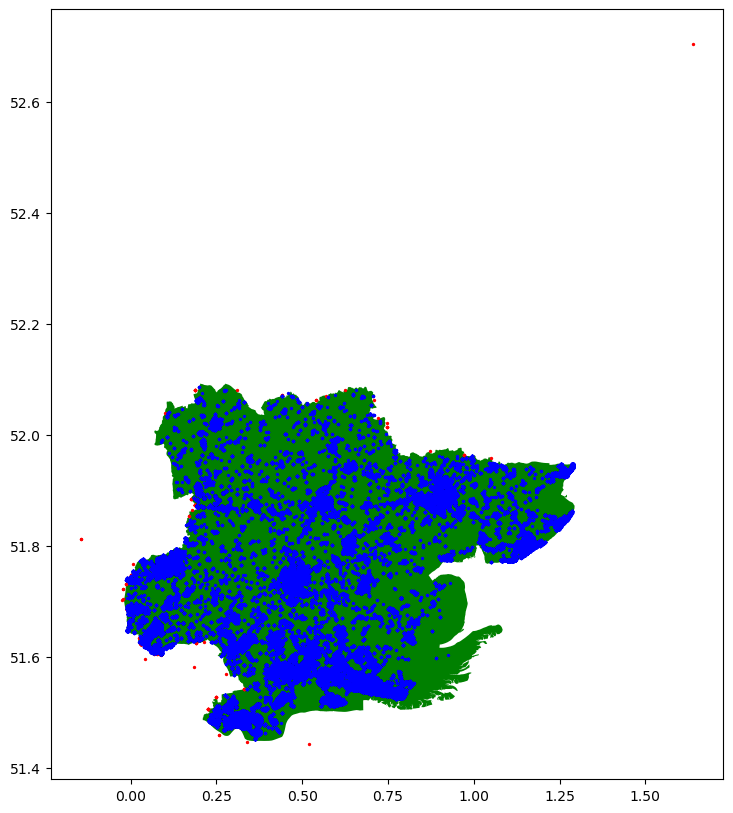

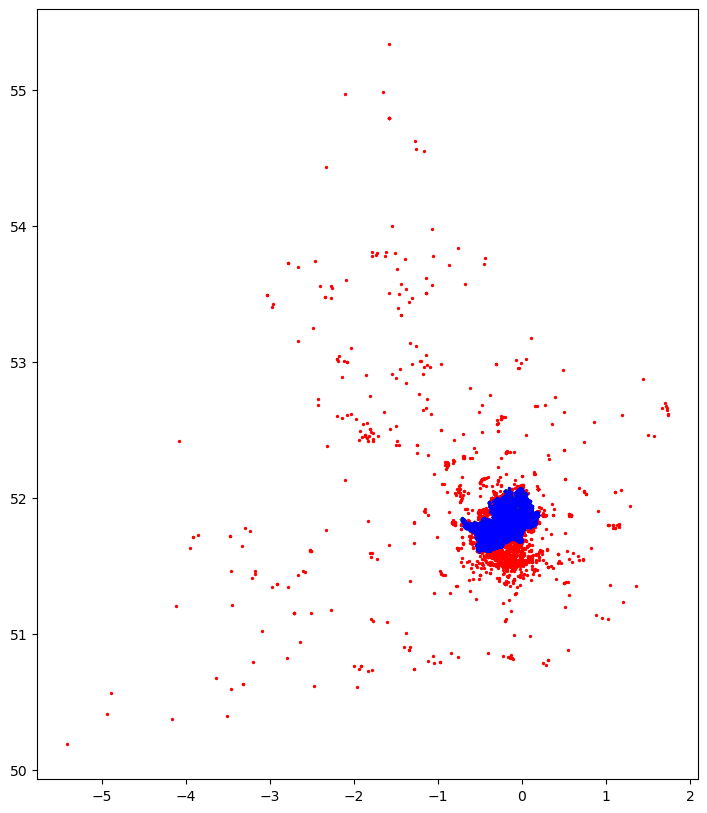

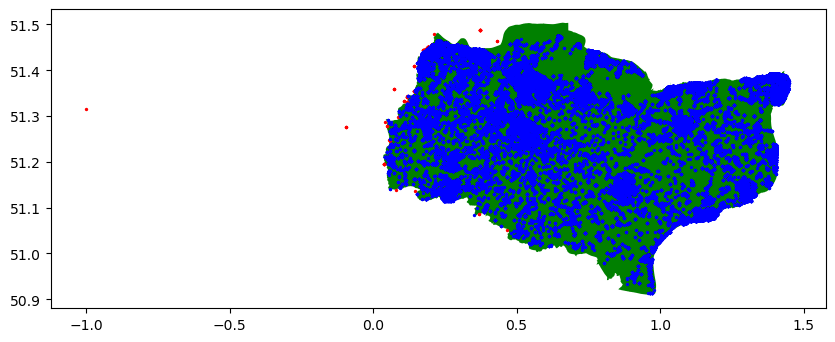

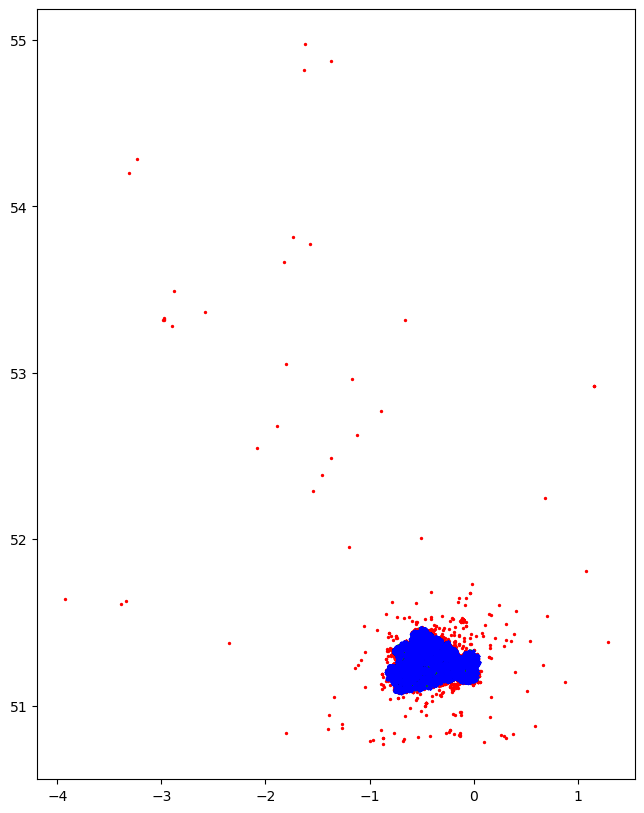

In [29]:
#Using Geopandas to map the data ontop of the boundary data reveals that there are many records in the data that fall outside of the boundaries
#This is most prevalent in the Hertfordshire and Surrey data, but also occurs in some values in the Essex and Kent data too
#Disclaimer: this cell may take a long time to execute
#essex
print('Essex loading...')
geometry = [Point(xy) for xy in zip(essex_data['Longitude'], essex_data['Latitude'])]
essex_gdf = gpd.GeoDataFrame(essex_data, geometry=geometry)
essex_gdf = essex_gdf.set_crs(epsg=4326)

essex_ax = essex_boundary.plot(figsize=(10,10),color='green',zorder=1)
essex_sj = essex_gdf.sjoin(essex_boundary,how='left',predicate='intersects')

essex_sj.loc[gpd.pd.isna(essex_sj.index_right)].plot(ax=essex_ax,markersize=2,color='red',zorder=2)
essex_sj.loc[~gpd.pd.isna(essex_sj.index_right)].plot(ax=essex_ax,markersize=2,color='blue',zorder=2)
print('Essex loaded')

#hertfordshire
print('Hertfordshire loading...')
geometry = [Point(xy) for xy in zip(herts_data['Longitude'], herts_data['Latitude'])]
herts_gdf = gpd.GeoDataFrame(herts_data, geometry=geometry)
herts_gdf = herts_gdf.set_crs(epsg=4326)

herts_ax = herts_boundary.plot(figsize=(10,10),color='green',zorder=1)
herts_sj = herts_gdf.sjoin(herts_boundary,how='left',predicate='intersects')

herts_sj.loc[gpd.pd.isna(herts_sj.index_right)].plot(ax=herts_ax,markersize=2,color='red',zorder=2)
herts_sj.loc[~gpd.pd.isna(herts_sj.index_right)].plot(ax=herts_ax,markersize=2,color='blue',zorder=2)
print('Hertfordshire loaded')

#kent
print('Kent loading...')
geometry = [Point(xy) for xy in zip(kent_data['Longitude'], kent_data['Latitude'])]
kent_gdf = gpd.GeoDataFrame(kent_data, geometry=geometry)
kent_gdf = kent_gdf.set_crs(epsg=4326)

kent_ax = kent_boundary.plot(figsize=(10,10),color='green',zorder=1)
kent_sj = kent_gdf.sjoin(kent_boundary,how='left',predicate='intersects')

kent_sj.loc[gpd.pd.isna(kent_sj.index_right)].plot(ax=kent_ax,markersize=2,color='red',zorder=2)
kent_sj.loc[~gpd.pd.isna(kent_sj.index_right)].plot(ax=kent_ax,markersize=2,color='blue',zorder=2)
print('Kent loaded')

#surrey
print('Surrey loading...')
geometry = [Point(xy) for xy in zip(surrey_data['Longitude'], surrey_data['Latitude'])]
surrey_gdf = gpd.GeoDataFrame(surrey_data, geometry=geometry)
surrey_gdf = surrey_gdf.set_crs(epsg=4326)

surrey_ax = surrey_boundary.plot(figsize=(10,10),color='green',zorder=1)
surrey_sj = surrey_gdf.sjoin(surrey_boundary,how='left',predicate='intersects')

surrey_sj.loc[gpd.pd.isna(surrey_sj.index_right)].plot(ax=surrey_ax,markersize=2,color='red',zorder=2)
surrey_sj.loc[~gpd.pd.isna(surrey_sj.index_right)].plot(ax=surrey_ax,markersize=2,color='blue',zorder=2)
print('Surrey loaded')

In [35]:
#Essex data fully cleaned with data only within the Essex PFA boundary
essex_cleaned = essex_sj.loc[~pd.isna(essex_sj.index_right)].drop(columns=['index_right','id','Name','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'])
essex_cleaned.info()
print('Essex clean as a proportion of the original data:',essex_cleaned.shape[0]/essex_raw.shape[0]*100,'%') #98.60%

#Herts data fully cleaned with data only within the Herts PFA boundary
herts_cleaned = herts_sj.loc[~pd.isna(herts_sj.index_right)].drop(columns=['index_right','id','Name','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'])
herts_cleaned.info()
print('Herts clean as a proportion of the original data:',herts_cleaned.shape[0]/herts_raw.shape[0]*100,'%') #97.42%

#Kent data fully cleaned with data only within the Kent PFA boundary
kent_cleaned = kent_sj.loc[~pd.isna(kent_sj.index_right)].drop(columns=['index_right','id','Name','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'])
kent_cleaned.info()
print('Kent clean as a proportion of the original data:',kent_cleaned.shape[0]/kent_raw.shape[0]*100,'%') #98.95%

#Surrey data fully cleaned with data only within the Surrey PFA boundary
surrey_cleaned = surrey_sj.loc[~pd.isna(surrey_sj.index_right)].drop(columns=['index_right','id','Name','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'])
surrey_cleaned.info()
print('Surrey clean as a proportion of the original data:',surrey_cleaned.shape[0]/surrey_raw.shape[0]*100,'%') #97.22%

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 339210 entries, 2 to 12642
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   Crime ID               305505 non-null  object  
 1   Month                  339210 non-null  object  
 2   Reported by            339210 non-null  object  
 3   Falls within           339210 non-null  object  
 4   Longitude              339210 non-null  float64 
 5   Latitude               339210 non-null  float64 
 6   Location               339210 non-null  object  
 7   LSOA code              339210 non-null  object  
 8   LSOA name              339210 non-null  object  
 9   Crime type             339210 non-null  object  
 10  Last outcome category  305505 non-null  object  
 11  Context                0 non-null       object  
 12  geometry               339210 non-null  geometry
dtypes: float64(2), geometry(1), object(10)
memory usage: 36.2+ MB
Essex clea

Essex loading...
Essex loaded
Hertfordshire loading...
Hertfordshire loaded
Kent loading...
Kent loaded
Surrey loading...
Surrey loaded


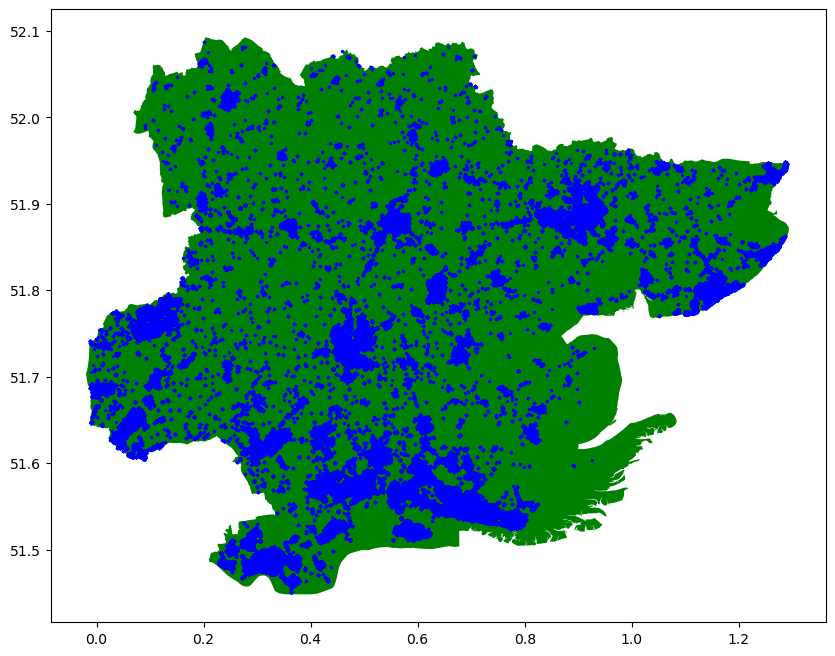

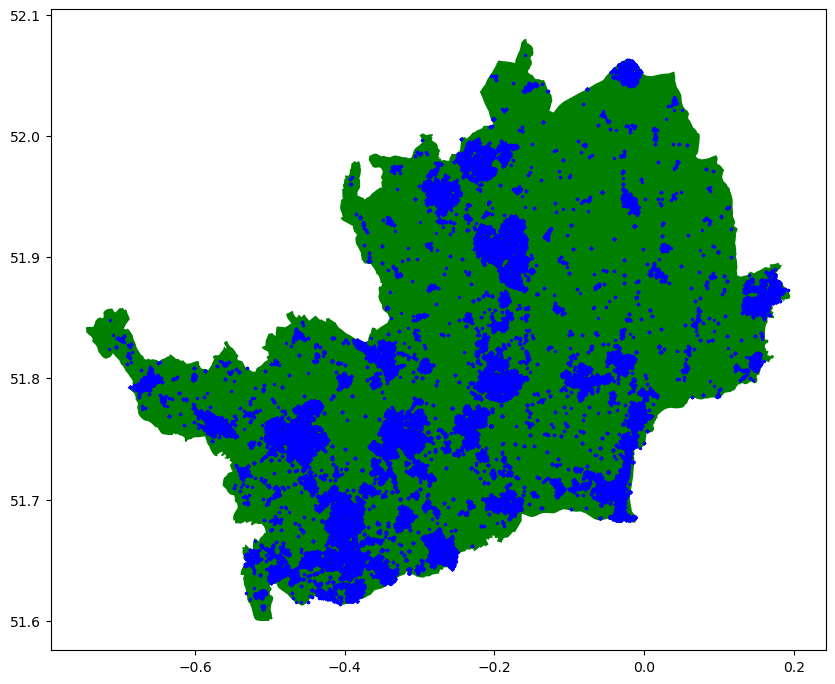

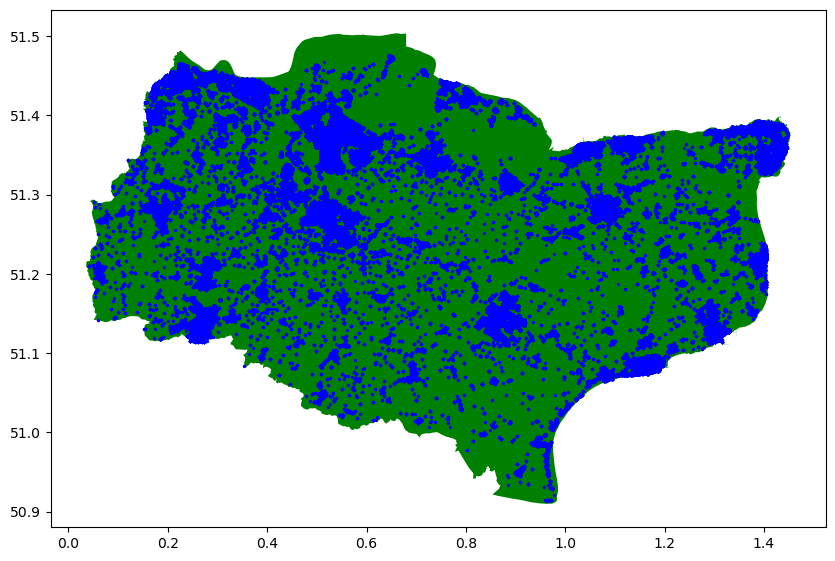

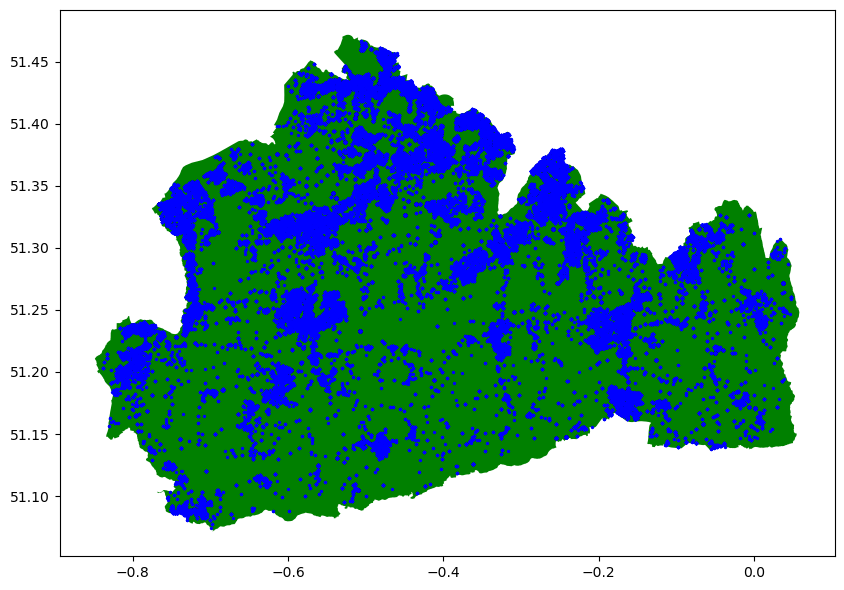

In [180]:
#essex
print('Essex loading...')
essex_ax = essex_boundary.plot(figsize=(10,10),color='green',zorder=1)
essex_sj = essex_cleaned.sjoin(essex_boundary,how='left',predicate='intersects')

essex_sj.loc[~gpd.pd.isna(essex_sj.index_right)].plot(ax=essex_ax,markersize=2,color='blue',zorder=2)
print('Essex loaded')

#hertfordshire
print('Hertfordshire loading...')
herts_ax = herts_boundary.plot(figsize=(10,10),color='green',zorder=1)
herts_sj = herts_cleaned.sjoin(herts_boundary,how='left',predicate='intersects')

herts_sj.loc[~gpd.pd.isna(herts_sj.index_right)].plot(ax=herts_ax,markersize=2,color='blue',zorder=2)
print('Hertfordshire loaded')

#kent
print('Kent loading...')
kent_ax = kent_boundary.plot(figsize=(10,10),color='green',zorder=1)
kent_sj = kent_cleaned.sjoin(kent_boundary,how='left',predicate='intersects')

kent_sj.loc[~gpd.pd.isna(kent_sj.index_right)].plot(ax=kent_ax,markersize=2,color='blue',zorder=2)
print('Kent loaded')

#surrey
print('Surrey loading...')
surrey_ax = surrey_boundary.plot(figsize=(10,10),color='green',zorder=1)
surrey_sj = surrey_cleaned.sjoin(surrey_boundary,how='left',predicate='intersects')

surrey_sj.loc[~gpd.pd.isna(surrey_sj.index_right)].plot(ax=surrey_ax,markersize=2,color='blue',zorder=2)
print('Surrey loaded')

In [79]:
#Now the LSOA data should be cleaned
#This means that unnecessary LSOAs can be dropped from lsoa_pop22, lsoa_pop23 and lsoa_pop24
LSOA = []
LSOA.extend(essex_cleaned['LSOA code'].unique())
LSOA.extend(herts_cleaned['LSOA code'].unique())
LSOA.extend(kent_cleaned['LSOA code'].unique())
LSOA.extend(surrey_cleaned['LSOA code'].unique())

lsoa_22_cleaned = lsoa_pop22[lsoa_pop22['LSOA 2021 Code'].isin(LSOA)==True]
lsoa_23_cleaned = lsoa_pop23[lsoa_pop23['LSOA 2021 Code'].isin(LSOA)==True]
lsoa_24_cleaned = lsoa_pop24[lsoa_pop24['LSOA 2021 Code'].isin(LSOA)==True]

In [80]:
#A column representing year can be added to each dataframe
lsoa_22_cleaned.insert(4,'Year','2022')
lsoa_23_cleaned.insert(4,'Year','2023')
lsoa_24_cleaned.insert(4,'Year','2024')

In [81]:
#Since lsoa_24_cleaned has columns 'LAD 2021 Code' and 'LAD 2021 Name' while lsoa_22 and lsoa_23 have 'LAD 2023 Code' and 'LAD 2023 Name'
#And they won't be needed for analysis, they can be dropped
lsoa_22_cleaned = lsoa_22_cleaned.drop(columns=['LAD 2023 Code','LAD 2023 Name'])
lsoa_23_cleaned = lsoa_23_cleaned.drop(columns=['LAD 2023 Code','LAD 2023 Name'])
lsoa_24_cleaned = lsoa_24_cleaned.drop(columns=['LAD 2021 Code','LAD 2021 Name'])

## PFA Population:

In [219]:
#Remove rows from the PFA data that aren't necessary (unrelated to the areas being looked at)
pfa_pop_clean = pfa_pop[(pfa_pop['PFA 2023 Name']=='Essex')|(pfa_pop['PFA 2023 Name']=='Hertfordshire')|(pfa_pop['PFA 2023 Name']=='Kent')|(pfa_pop['PFA 2023 Name']=='Surrey')]
pfa_pop_clean.reset_index(drop=True)

,PFA 2023 Code,PFA 2023 Name,Year,F0,F1,F2,F3,F4,F5,F6,...,M76,M77,M78,M79,M80,M81,M82,M83,M84,M85
0,E23000027,Hertfordshire,2021,6421,6693,6749,6908,7051,7459,7328,...,3958,3908,3551,2874,2421,2547,2571,2363,2249,11574
1,E23000027,Hertfordshire,2022,6432,6546,6840,6837,7111,7160,7574,...,3909,3844,3758,3407,2744,2329,2443,2401,2193,12011
2,E23000027,Hertfordshire,2023,6176,6674,6776,7079,7039,7354,7344,...,5187,3775,3714,3585,3232,2622,2213,2307,2208,12237
3,E23000027,Hertfordshire,2024,6051,6385,6892,7002,7173,7257,7513,...,4572,5039,3676,3594,3397,3116,2487,2079,2156,12571
4,E23000028,Essex,2021,9486,10108,10356,10744,10677,10882,10799,...,7452,7325,6630,5526,4552,4703,4538,4292,3820,18843
5,E23000028,Essex,2022,9987,9826,10470,10589,10982,10902,11029,...,7812,7199,7050,6330,5301,4293,4400,4240,3987,19360
6,E23000028,Essex,2023,9491,10315,10209,10829,11001,11351,11196,...,10346,7499,6928,6750,6005,4987,4015,4104,3893,19876
7,E23000028,Essex,2024,9524,9875,10694,10590,11144,11375,11644,...,9104,10004,7257,6614,6447,5701,4702,3763,3815,20563
8,E23000031,Surrey,2021,6004,6221,6409,6464,6709,7094,7111,...,4399,4374,4099,3408,2804,2971,2816,2617,2494,13514
9,E23000031,Surrey,2022,6048,6232,6503,6661,6627,6901,7272,...,4703,4271,4229,3945,3273,2697,2806,2640,2430,13942


In [220]:
#Reduce number of columns by grouping the ages in similar buckets to the LSOA data
#and create total columns for male, female and overall
#F0-15
F015 = pfa_pop_clean.iloc[:,3:19].sum(axis=1)
#F16-29
F1629 = pfa_pop_clean.iloc[:,19:33].sum(axis=1)
#F30-44
F3044 = pfa_pop_clean.iloc[:,33:48].sum(axis=1)
#F45-64
F4564 = pfa_pop_clean.iloc[:,48:69].sum(axis=1)
#F65-Over
F65Over = pfa_pop_clean.iloc[:,69:89].sum(axis=1)
#M0-15
M015 = pfa_pop_clean.iloc[:,89:105].sum(axis=1)
#M16-29
M1629 = pfa_pop_clean.iloc[:,105:119].sum(axis=1)
#M30-44
M3044 = pfa_pop_clean.iloc[:,119:134].sum(axis=1)
#M45-64
M4564 = pfa_pop_clean.iloc[:,134:154].sum(axis=1)
#M65-Over
M65Over = pfa_pop_clean.iloc[:,154:175].sum(axis=1)
#FTotal
FTotal = pfa_pop_clean.iloc[:,3:89].sum(axis=1)
#MTotal
MTotal = pfa_pop_clean.iloc[:,89:175].sum(axis=1)
#Total
Total = pfa_pop_clean.iloc[:,3:175].sum(axis=1)

In [221]:
#F0-15,F16-29,F30-44,F45-64,F65-Over and M0-15,M16-29,M30-44,M45-64,M65-Over
pfa_pop_clean.insert(3,'Total',Total)
pfa_pop_clean.insert(3,'MTotal',MTotal)
pfa_pop_clean.insert(3,'FTotal',FTotal)
pfa_pop_clean.insert(3,'M65 and over',M65Over)
pfa_pop_clean.insert(3,'M45 to 64',M4564)
pfa_pop_clean.insert(3,'M30 to 44',M3044)
pfa_pop_clean.insert(3,'M16 to 29',M1629)
pfa_pop_clean.insert(3,'M0 to 15',M015)
pfa_pop_clean.insert(3,'F65 and over',F65Over)
pfa_pop_clean.insert(3,'F45 to 64',F4564)
pfa_pop_clean.insert(3,'F30 to 44',F3044)
pfa_pop_clean.insert(3,'F16 to 29',F1629)
pfa_pop_clean.insert(3,'F0 to 15',F015)


pfa_pop_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 104 to 127
Columns: 188 entries, PFA 2023 Code to M85
dtypes: int64(186), object(2)
memory usage: 23.6+ KB


In [222]:
#Drop the unnecessary columns
x=0
for i in range(0,86):
    pfa_pop_clean = pfa_pop_clean.drop(columns=['F'+str(x),'M'+str(x)])
    x=x+1

pfa_pop_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 104 to 127
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PFA 2023 Code  16 non-null     object
 1   PFA 2023 Name  16 non-null     object
 2   Year           16 non-null     int64 
 3   F0 to 15       16 non-null     int64 
 4   F16 to 29      16 non-null     int64 
 5   F30 to 44      16 non-null     int64 
 6   F45 to 64      16 non-null     int64 
 7   F65 and over   16 non-null     int64 
 8   M0 to 15       16 non-null     int64 
 9   M16 to 29      16 non-null     int64 
 10  M30 to 44      16 non-null     int64 
 11  M45 to 64      16 non-null     int64 
 12  M65 and over   16 non-null     int64 
 13  FTotal         16 non-null     int64 
 14  MTotal         16 non-null     int64 
 15  Total          16 non-null     int64 
dtypes: int64(14), object(2)
memory usage: 2.1+ KB


## PFA Boundaries:

In [177]:
#Filling the null value in name to hold the name of the PFA
essex_boundary.fillna({'Name':'Essex'},inplace=True)
herts_boundary.fillna({'Name':'Hertfordshire'},inplace=True)
kent_boundary.fillna({'Name':'Kent'},inplace=True)
surrey_boundary.fillna({'Name':'Surrey'},inplace=True)

In [178]:
#Dropping the unnecessary columns
essex_boundary.drop(columns=['id','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'],inplace=True)
herts_boundary.drop(columns=['id','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'],inplace=True)
kent_boundary.drop(columns=['id','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'],inplace=True)
surrey_boundary.drop(columns=['id','description','timestamp','begin','end','altitudeMode','tessellate','extrude','visibility','drawOrder','icon'],inplace=True)

# Combining Data

## Police Forces:

In [214]:
forces_combined = pd.concat([essex_cleaned,herts_cleaned,kent_cleaned,surrey_cleaned])
forces_combined.reset_index(drop=True,inplace=True)
forces_combined

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,geometry
0,dae64ebb12ae13cbd83cdfc911aee12398c57f202c2aab...,2022-07,Essex Police,Essex Police,0.435461,51.637725,On or near Shire Close,E01021237,Basildon 001A,Vehicle crime,Investigation complete; no suspect identified,NaN,POINT (0.43546 51.63772)
1,20b2033fda32e88ae16fb901249b1ce42c8c18af468ea7...,2022-07,Essex Police,Essex Police,0.439004,51.641536,On or near Derby Close,E01021237,Basildon 001A,Violence and sexual offences,Unable to prosecute suspect,NaN,POINT (0.439 51.64154)
2,74ccf11ec7f3ff08c4adb16d295a786c1f54a2cb548ac9...,2022-07,Essex Police,Essex Police,0.435776,51.639823,On or near Coach Mews,E01021237,Basildon 001A,Violence and sexual offences,Unable to prosecute suspect,NaN,POINT (0.43578 51.63982)
3,afa0310e898cd3a7ba99b11e3ab6def44514cfeae29e90...,2022-07,Essex Police,Essex Police,0.439614,51.639167,On or near Smythe Road,E01021237,Basildon 001A,Violence and sexual offences,Unable to prosecute suspect,NaN,POINT (0.43961 51.63917)
4,31565e27a8bfb974e117c7beb88734bb25fc759091eb7e...,2022-07,Essex Police,Essex Police,0.434447,51.627979,On or near Shalford Road,E01021242,Basildon 001C,Violence and sexual offences,Local resolution,NaN,POINT (0.43445 51.62798)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1092623,f5515dddabbe93609a8d64b7069fb257b5ce70df8d767b...,2024-06,Surrey Police,Surrey Police,-0.576697,51.283495,On or near Parking Area,E01030987,Woking 012E,Drugs,Local resolution,NaN,POINT (-0.5767 51.2835)
1092624,3c3e3930da60cde347083510da2c8ecb9ee36148a4d49a...,2024-06,Surrey Police,Surrey Police,-0.570539,51.294777,On or near Bourne Way,E01030987,Woking 012E,Shoplifting,Under investigation,NaN,POINT (-0.57054 51.29478)
1092625,1f940e6cffcf9c27e048ecc306c38f2c3eb3c500123003...,2024-06,Surrey Police,Surrey Police,-0.572891,51.287846,On or near Maybourne Rise,E01030987,Woking 012E,Vehicle crime,Under investigation,NaN,POINT (-0.57289 51.28785)
1092626,f1039fac2d040f36008574be11926068cf427f13683de6...,2024-06,Surrey Police,Surrey Police,-0.570539,51.294777,On or near Bourne Way,E01030987,Woking 012E,Violence and sexual offences,Under investigation,NaN,POINT (-0.57054 51.29478)


## LSOA Population:

In [215]:
#Now the LSOA dataframes can be combined
lsoa_combined = pd.concat([lsoa_22_cleaned,lsoa_23_cleaned,lsoa_24_cleaned])
lsoa_combined.reset_index(drop=True,inplace=True)
lsoa_combined

,LSOA 2021 Code,LSOA 2021 Name,Year,Total,F0 to 15,F16 to 29,F30 to 44,F45 to 64,F65 and over,M0 to 15,M16 to 29,M30 to 44,M45 to 64,M65 and over
0,E01015814,Southend-on-Sea 003A,2022,1350,105,76,117,194,192,115,96,117,177,161
1,E01015815,Southend-on-Sea 003B,2022,1657,154,106,149,247,221,139,129,131,217,164
2,E01015816,Southend-on-Sea 003C,2022,1599,113,82,121,198,332,86,84,107,206,270
3,E01015817,Southend-on-Sea 003D,2022,1644,96,72,118,217,340,117,103,109,196,276
4,E01015818,Southend-on-Sea 003E,2022,1660,121,99,143,199,298,155,113,139,189,204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10960,E01035570,Stevenage 008E,2024,1724,114,167,316,85,95,118,309,329,142,49
10961,E01035571,Stevenage 008F,2024,1475,161,125,214,143,112,174,106,187,162,91
10962,E01035582,Stevenage 013A,2024,1622,126,110,149,260,149,119,129,155,274,151
10963,E01000290,Barnet 007F,2024,1588,109,95,129,242,210,149,134,115,224,181


## PFA Population:

In [223]:
#Already just a single dataframe
pfa_pop_clean.reset_index(drop=True,inplace=True)
pfa_pop_clean

,PFA 2023 Code,PFA 2023 Name,Year,F0 to 15,F16 to 29,F30 to 44,F45 to 64,F65 and over,M0 to 15,M16 to 29,M30 to 44,M45 to 64,M65 and over,FTotal,MTotal,Total
0,E23000027,Hertfordshire,2021,116917,92267,131439,167245,106836,122374,93770,120582,156653,92816,614704,586195,1200899
1,E23000027,Hertfordshire,2022,118000,90181,133186,167787,108299,123522,92793,120901,156323,94566,617453,588105,1205558
2,E23000027,Hertfordshire,2023,119577,90669,136447,168955,109690,124932,94615,123103,156858,96105,625338,595613,1220951
3,E23000027,Hertfordshire,2024,119859,92021,138562,170602,111677,125431,97107,125120,157648,98164,632721,603470,1236191
4,E23000028,Essex,2021,172115,142798,188897,259286,192408,180944,144094,174488,240282,168002,955504,907810,1863314
5,E23000028,Essex,2022,174608,140419,193519,259771,194870,183346,143514,177355,239925,170163,963187,914303,1877490
6,E23000028,Essex,2023,177674,141689,200101,260740,196885,186672,145607,182606,240268,172297,977089,927450,1904539
7,E23000028,Essex,2024,179825,142694,205038,262447,200036,188635,147724,186638,241156,175417,990040,939570,1929610
8,E23000031,Surrey,2021,112486,90843,123113,171971,119161,117707,92405,113439,161454,103415,617574,588420,1205994
9,E23000031,Surrey,2022,114431,90164,125603,173517,120797,119832,92258,114544,161912,104857,624512,593403,1217915


## PFA Boundaries:

In [218]:
#Combine all the boundary data into a single geodataframe
boundaries_combined = pd.concat([essex_boundary,herts_boundary,kent_boundary,surrey_boundary])
boundaries_combined.reset_index(drop=True,inplace=True)
boundaries_combined

,Name,geometry
0,Essex,"MULTIPOLYGON Z (((0.2475 52.0791 0, 0.24835 52..."
1,Hertfordshire,"MULTIPOLYGON Z (((-0.34146 51.84833 0, -0.3395..."
2,Kent,"MULTIPOLYGON Z (((0.16235 51.13676 0, 0.16237 ..."
3,Surrey,"MULTIPOLYGON Z (((-0.17672 51.16685 0, -0.1773..."


# Data Frame To CSV

In [226]:
forces_combined.to_csv('forces_combined_clean.csv')
lsoa_combined.to_csv('lsoa_combined_clean.csv')
pfa_pop_clean.to_csv('pfa_pop_clean.csv')
boundaries_combined.to_csv('boundaries_combined_clean.csv')